In [78]:
import mofr

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLagRegression_strategy.backtest_class import BacktestLL
from Strategies.LeadLagRegression_strategy.strategy_class import StrategyLL, VolumeClass
from support_functions import calculate_MACD, calculate_lead_lag_triggers, calculate_regression_model_price
tol=(1e-1)/2

import seaborn as sns


In [80]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_tree
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [81]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [82]:
import warnings
warnings.filterwarnings('ignore')

In [83]:
max_secs_between_trades=60
cluster_trade_num_threshold=5
min_price_movement=0.05

burnout_period=30
stop_profit=0.3
makeagg_ratio=0.6

take_profit=0.5
stop_loss=-0.4

br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

In [84]:
##########################
param_dict = {}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio

param_dict['br_fee'] = br_fee
##########################


strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.param_dict=param_dict

# Data preparation

In [85]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_oot_may_june.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dew1_oot_may_june.csv',
                    parse_dates=['datetime']).reset_index()

In [86]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [87]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [88]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [89]:
data_lag['date']=data_lag['datetime'].apply(lambda x: x.date())

In [90]:
data_lag=calculate_MACD(data_lag)
data_lag=calculate_lead_lag_triggers(data_lead, data_lag, max_secs_between_trades, cluster_trade_num_threshold, min_price_movement)
data_lag=calculate_regression_model_price(data_lead, data_lag, 10, 10, 5)

In [91]:
def calc_time_since_predicted_price(row):
    
        return (row['datetime']-row['lag_price_predicted_datetime']).total_seconds()
   

In [92]:
 data_lag['time_since_predicted_price']=data_lag[['datetime', 'lag_price_predicted_datetime']].apply(lambda row: calc_time_since_predicted_price(row), axis=1)

In [93]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff,date,MACD,trigger_datetime,trigger_action,lag_price_predicted,lag_price_predicted_datetime,time_since_predicted_price
0,16,2024-05-01 09:01:34,NaN,NaN,62.0,63.00,62.500,1,443.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN
1,17,2024-05-01 09:01:41,NaN,NaN,61.0,63.00,62.000,1,7.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN
2,18,2024-05-01 09:01:48,NaN,NaN,61.0,62.75,61.875,1,7.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN
3,19,2024-05-01 09:02:36,NaN,NaN,61.5,62.75,62.125,1,48.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN
4,20,2024-05-01 09:25:23,NaN,NaN,62.0,62.75,62.375,1,1367.0,2024-05-01,NaN,NaT,NaN,NaN,NaT,NaN


# Target Calculation

In [94]:
def calculate_close_slot_long(open_price, open_time, row):
    
        if row['ask_price']-row['bid_price']>param_dict['ba_max']:
            return (0,0)
    
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        
        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=1
        
        return strategy_class.calculate_close_slot()
    
def calculate_close_slot_short(open_price, open_time, row):

        if row['ask_price']-row['bid_price']>param_dict['ba_max']:
            return (0,0)
        
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        
        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=-1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=-1
        
        return strategy_class.calculate_close_slot()

    
def calculate_profit_long(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['ask_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_long(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return price-open_price-2*param_dict['br_fee']
    
    return 0

def calculate_profit_short(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['bid_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_short(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return open_price-price-2*param_dict['br_fee']
    
    return 0

In [95]:
df_filtered=data_lag[data_lag['time_since_predicted_price']<data_lag['time_diff']]

In [96]:
for date in sorted(list(set(df_filtered.date))):
    print(date)
    a=data_lag[data_lag['date']==date]
    df_filtered.loc[df_filtered['date']==date, 'profit_long']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_long(row, a), axis=1)
    df_filtered.loc[df_filtered['date']==date, 'profit_short']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_short(row, a), axis=1)

2024-05-02
2024-05-03
2024-05-06



KeyboardInterrupt



In [ ]:
df_filtered=df_filtered[df_filtered['datetime'].apply(lambda x: x.hour>8 and  x.hour<17)]

In [97]:
df_filtered.to_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_oot_may_june_enriched.csv')


KeyboardInterrupt



In [98]:
df_filtered=pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dew1_oot_may_june_enriched.csv')

# Model Calculation

In [99]:
seed=2

In [100]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import r2_score

## Long model 

In [101]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['ask_price']

In [102]:
fil1=df_filtered['MACD'].isnull()==False
fil2=df_filtered['price_diff'].isnull()==False
fil3=df_filtered['trigger_action'].isnull()==False
fil4=df_filtered['profit_long'].isnull()==False

In [103]:
df_modelling=df_filtered[fil1&fil2&fil3&fil4]

### Regression

In [104]:
# Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
X_train = df_modelling[['MACD', 'price_diff', 'trigger_action']]
y_train = df_modelling['profit_long'].fillna(0)

# Add a constant to the independent variable
X_train = sm.add_constant(X_train)

# Fit the model using statsmodels
model = sm.OLS(y_train, X_train).fit()

# Predict the lag_log_ret for the current day using the model
# X_test = sm.add_constant(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lead_log_ret'].fillna(0))
# r_squared_test = r2_score(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret'].fillna(0), model.predict(X_test).fillna(0))

# Optionally, print the summary for each model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            profit_long   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     36.60
Date:                Tue, 06 Aug 2024   Prob (F-statistic):           1.60e-23
Time:                        13:38:52   Log-Likelihood:                -5272.3
No. Observations:               10701   AIC:                         1.055e+04
Df Residuals:                   10697   BIC:                         1.058e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.1071      0.004    -25.

### XGBoost

In [105]:
df_modelling['y']=(df_modelling['profit_long']>0).apply(int)
df_modelling['y'].value_counts()

y
0    6666
1    4035
Name: count, dtype: int64

In [106]:
feature_cols=['MACD', 'price_diff', 'trigger_action']

In [107]:
X_train, X_test, y_train, y_test = train_test_split(df_modelling[feature_cols], df_modelling['y'], test_size=0.25, random_state=seed)

xgb_model = XGBClassifier(max_depth=3, gamma=1, min_child_weight=5, n_estimators=10)
xgb_model.fit(X_train,
              y_train)
df_modelling['XGB_SCORE']=xgb_model.predict_proba(df_modelling[feature_cols])[:, 1]
X_train['XGB_SCORE']=xgb_model.predict_proba(X_train[feature_cols])[:, 1]
X_test['XGB_SCORE']=xgb_model.predict_proba(X_test[feature_cols])[:, 1]

preds_ = xgb_model.predict_proba(X_test[feature_cols])

In [108]:
print('The Lift on the df set is: '+ str(mofr.metrics.lift(y_train, X_train['XGB_SCORE'])))
print('The gini on the df set is: '+ str(mofr.metrics.gini(y_train, X_train['XGB_SCORE'])))
print('The accuracy on the df set is: '+ str(mofr.metrics.accuracy_score(y_train, X_train['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(y_test, X_test['XGB_SCORE'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(y_test, X_test['XGB_SCORE'])))
print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(y_test, X_test['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')

The Lift on the df set is: 1.715542992173375
The gini on the df set is: 0.28775113706493527
The accuracy on the df set is: 0.6544548286604361


The Lift on the test set is: 1.4348244687096394
The gini on the test set is: 0.22377824995170936
The accuracy on the test set is: 0.6401345291479821




In [109]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD,0.128584
1,price_diff,0.062780
2,trigger_action,0.016682


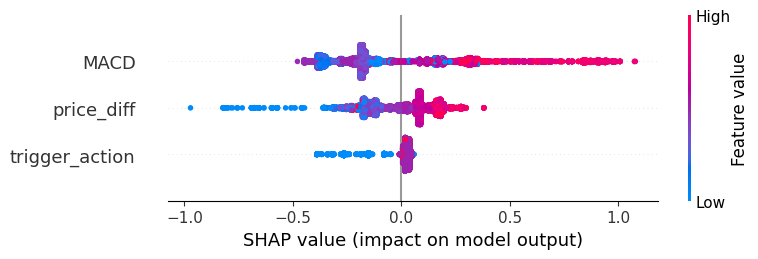

In [110]:
import shap
%matplotlib inline

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df_modelling[feature_cols])
shap.summary_plot(shap_values, df_modelling[feature_cols])
plt.show()

#### **Precision curve**

In [111]:
preds_p = xgb_model.predict_proba(X_test[feature_cols])[:, 1]
#preds_p = model.predict(X_test).apply(lambda x: 1/(1+np.exp(-x)))

# threshold for more certainty in predicted values
thold_list = np.arange(0.2, 0.6, 0.001)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [1 if x > thold else 0 for x in preds_p]
    cm = confusion_matrix(y_test, preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

In [112]:
prec_recall_df[-50:]

,thold,precision,recall,count
350,0.550,0.586420,0.094810,162
351,0.551,0.586420,0.094810,162
352,0.552,0.586420,0.094810,162
353,0.553,0.586420,0.094810,162
354,0.554,0.586420,0.094810,162
355,0.555,0.586420,0.094810,162
356,0.556,0.586420,0.094810,162
357,0.557,0.586420,0.094810,162
358,0.558,0.586420,0.094810,162
359,0.559,0.583851,0.093812,161


### Interactions

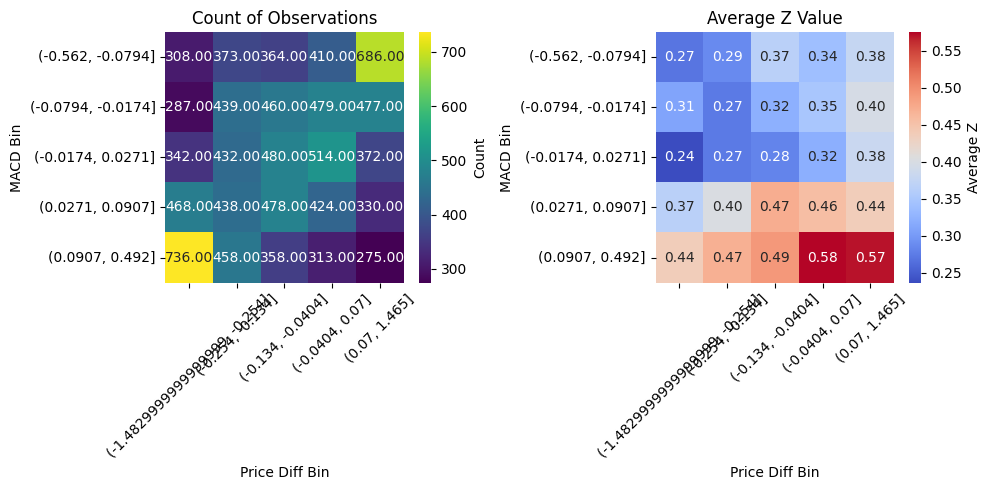

In [113]:
# Binning with interval labels
df_modelling.loc[:,'MACD_bin'] = pd.qcut(df_modelling['MACD'], 5, retbins=False, precision=3)
df_modelling.loc[:,'price_diff_bin'] = pd.qcut(df_modelling['price_diff'], 5, retbins=False, precision=3)


# Create pivot tables
count_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='count')
mean_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='mean')

# Setup figure for heatmaps
plt.figure(figsize=(10,5))

# Heatmap for count of observations
plt.subplot(1, 2, 1)
sns.heatmap(count_pivot, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Count'})
plt.title('Count of Observations')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(count_pivot.columns)) + 0.5, count_pivot.columns, rotation=45)
plt.yticks(np.arange(len(count_pivot.index)) + 0.5, count_pivot.index, rotation=0)

# Heatmap for average of Z
plt.subplot(1, 2, 2)
sns.heatmap(mean_pivot, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Average Z'})
plt.title('Average Z Value')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(mean_pivot.columns)) + 0.5, mean_pivot.columns, rotation=45)
plt.yticks(np.arange(len(mean_pivot.index)) + 0.5, mean_pivot.index, rotation=0)

plt.tight_layout()
plt.show()

In [114]:
count_pivot

price_diff_bin,"(-1.4829999999999999, -0.254]","(-0.254, -0.134]","(-0.134, -0.0404]","(-0.0404, 0.07]","(0.07, 1.465]"
MACD_bin,,,,,
"(-0.562, -0.0794]",308,373,364,410,686
"(-0.0794, -0.0174]",287,439,460,479,477
"(-0.0174, 0.0271]",342,432,480,514,372
"(0.0271, 0.0907]",468,438,478,424,330
"(0.0907, 0.492]",736,458,358,313,275


In [115]:
mean_pivot

price_diff_bin,"(-1.4829999999999999, -0.254]","(-0.254, -0.134]","(-0.134, -0.0404]","(-0.0404, 0.07]","(0.07, 1.465]"
MACD_bin,,,,,
"(-0.562, -0.0794]",0.269481,0.286863,0.365385,0.339024,0.377551
"(-0.0794, -0.0174]",0.310105,0.273349,0.321739,0.348643,0.396226
"(-0.0174, 0.0271]",0.236842,0.273148,0.281250,0.321012,0.381720
"(0.0271, 0.0907]",0.365385,0.401826,0.472803,0.455189,0.436364
"(0.0907, 0.492]",0.437500,0.469432,0.491620,0.575080,0.570909


## Short model 

In [116]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['bid_price']

In [117]:
fil1=df_filtered['MACD'].isnull()==False
fil2=df_filtered['price_diff'].isnull()==False
fil3=df_filtered['trigger_action'].isnull()==False
fil4=df_filtered['profit_long'].isnull()==False

In [118]:
df_modelling=df_filtered[fil1&fil2&fil3&fil4]

In [119]:
# Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
X_train = df_modelling[['MACD', 'price_diff', 'trigger_action']]
y_train = df_modelling['profit_short'].fillna(0)

# Add a constant to the independent variable
X_train = sm.add_constant(X_train)

# Fit the model using statsmodels
model = sm.OLS(y_train, X_train).fit()

# Predict the lag_log_ret for the current day using the model
# X_test = sm.add_constant(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lead_log_ret'].fillna(0))
# r_squared_test = r2_score(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret'].fillna(0), model.predict(X_test).fillna(0))

# Optionally, print the summary for each model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           profit_short   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     38.21
Date:                Tue, 06 Aug 2024   Prob (F-statistic):           1.50e-24
Time:                        13:38:55   Log-Likelihood:                -5535.4
No. Observations:               10701   AIC:                         1.108e+04
Df Residuals:                   10697   BIC:                         1.111e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.1476      0.004    -36.

### XGBoost

In [120]:
df_modelling['y']=(df_modelling['profit_short']>0).apply(int)
df_modelling['y'].value_counts()

y
0    7117
1    3584
Name: count, dtype: int64

In [121]:
feature_cols=['MACD', 'price_diff', 'trigger_action']

In [122]:
X_train, X_test, y_train, y_test = train_test_split(df_modelling[feature_cols], df_modelling['y'], test_size=0.25, random_state=seed)

xgb_model = XGBClassifier(max_depth=3, gamma=1, min_child_weight=5, n_estimators=10)
xgb_model.fit(X_train,
              y_train)
df_modelling['XGB_SCORE']=xgb_model.predict_proba(df_modelling[feature_cols])[:, 1]
X_train['XGB_SCORE']=xgb_model.predict_proba(X_train[feature_cols])[:, 1]
X_test['XGB_SCORE']=xgb_model.predict_proba(X_test[feature_cols])[:, 1]

preds_ = xgb_model.predict_proba(X_test[feature_cols])

In [123]:
print('The Lift on the df set is: '+ str(mofr.metrics.lift(y_train, X_train['XGB_SCORE'])))
print('The gini on the df set is: '+ str(mofr.metrics.gini(y_train, X_train['XGB_SCORE'])))
print('The accuracy on the df set is: '+ str(mofr.metrics.accuracy_score(y_train, X_train['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(y_test, X_test['XGB_SCORE'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(y_test, X_test['XGB_SCORE'])))
print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(y_test, X_test['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')

The Lift on the df set is: 1.7483660130718957
The gini on the df set is: 0.2610215266910101
The accuracy on the df set is: 0.6681619937694704


The Lift on the test set is: 1.6933478961876527
The gini on the test set is: 0.2414419794360052
The accuracy on the test set is: 0.6711509715994021




In [124]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD,-0.091904
1,price_diff,-0.026657
2,trigger_action,-0.012011


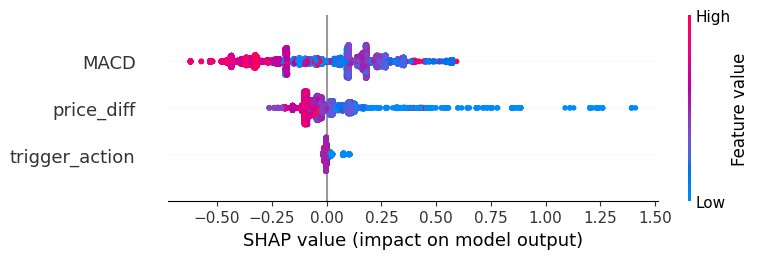

In [125]:
import shap
%matplotlib inline

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df_modelling[feature_cols])
shap.summary_plot(shap_values, df_modelling[feature_cols])
plt.show()

#### **Precision curve**

In [126]:
preds_p = xgb_model.predict_proba(X_test[feature_cols])[:, 1]
#preds_p = model.predict(X_test).apply(lambda x: 1/(1+np.exp(-x)))

# threshold for more certainty in predicted values
thold_list = np.arange(0.2, 0.45, 0.001)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [1 if x > thold else 0 for x in preds_p]
    cm = confusion_matrix(y_test, preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

In [127]:
prec_recall_df[-50:]

,thold,precision,recall,count
200,0.400,0.534759,0.226244,374
201,0.401,0.534759,0.226244,374
202,0.402,0.532258,0.223982,372
203,0.403,0.532258,0.223982,372
204,0.404,0.532258,0.223982,372
205,0.405,0.567010,0.186652,291
206,0.406,0.567010,0.186652,291
207,0.407,0.566901,0.182127,284
208,0.408,0.566901,0.182127,284
209,0.409,0.566901,0.182127,284


### Interactions

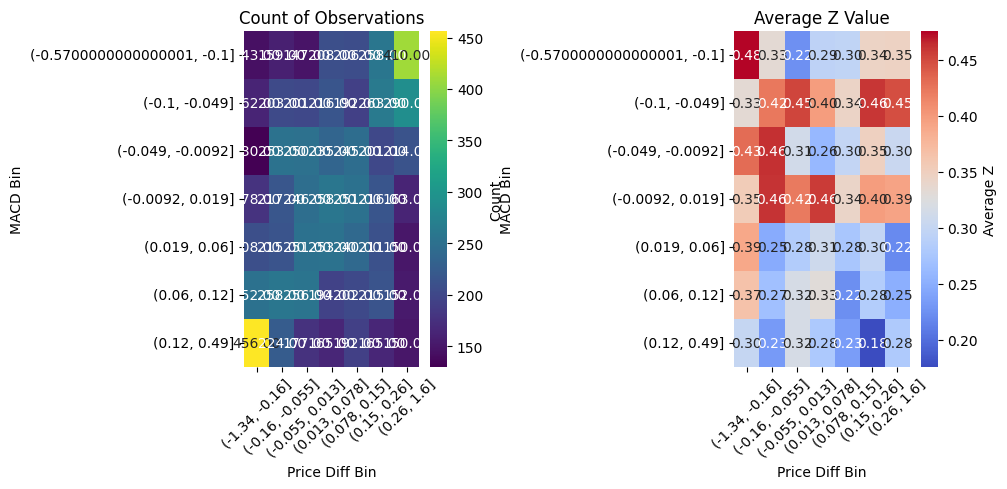

In [128]:
# Binning with interval labels
df_modelling.loc[:,'MACD_bin'] = pd.qcut(df_modelling['MACD'], 7, retbins=False, precision=2)
df_modelling.loc[:,'price_diff_bin'] = pd.qcut(df_modelling['price_diff'], 7, retbins=False, precision=2)


# Create pivot tables
count_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='count')
mean_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='mean')

# Setup figure for heatmaps
plt.figure(figsize=(10,5))

# Heatmap for count of observations
plt.subplot(1, 2, 1)
sns.heatmap(count_pivot, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Count'})
plt.title('Count of Observations')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(count_pivot.columns)) + 0.5, count_pivot.columns, rotation=45)
plt.yticks(np.arange(len(count_pivot.index)) + 0.5, count_pivot.index, rotation=0)

# Heatmap for average of Z
plt.subplot(1, 2, 2)
sns.heatmap(mean_pivot, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Average Z'})
plt.title('Average Z Value')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(mean_pivot.columns)) + 0.5, mean_pivot.columns, rotation=45)
plt.yticks(np.arange(len(mean_pivot.index)) + 0.5, mean_pivot.index, rotation=0)

plt.tight_layout()
plt.show()

In [129]:
count_pivot

price_diff_bin,"(-1.34, -0.16]","(-0.16, -0.055]","(-0.055, 0.013]","(0.013, 0.078]","(0.078, 0.15]","(0.15, 0.26]","(0.26, 1.6]"
MACD_bin,,,,,,,
"(-0.5700000000000001, -0.1]",143,159,147,208,206,258,410
"(-0.1, -0.049]",162,203,201,216,192,263,290
"(-0.049, -0.0092]",130,253,250,235,245,201,214
"(-0.0092, 0.019]",178,217,246,258,251,216,163
"(0.019, 0.06]",208,215,251,253,240,211,150
"(0.06, 0.12]",252,258,256,194,202,215,152
"(0.12, 0.49]",456,224,177,165,192,165,150


In [130]:
mean_pivot

price_diff_bin,"(-1.34, -0.16]","(-0.16, -0.055]","(-0.055, 0.013]","(0.013, 0.078]","(0.078, 0.15]","(0.15, 0.26]","(0.26, 1.6]"
MACD_bin,,,,,,,
"(-0.5700000000000001, -0.1]",0.475524,0.333333,0.224490,0.293269,0.296117,0.344961,0.346341
"(-0.1, -0.049]",0.333333,0.423645,0.452736,0.398148,0.343750,0.460076,0.448276
"(-0.049, -0.0092]",0.430769,0.462451,0.312000,0.259574,0.297959,0.348259,0.303738
"(-0.0092, 0.019]",0.353933,0.460829,0.422764,0.457364,0.342629,0.398148,0.392638
"(0.019, 0.06]",0.389423,0.246512,0.282869,0.308300,0.275000,0.298578,0.220000
"(0.06, 0.12]",0.365079,0.267442,0.316406,0.329897,0.222772,0.283721,0.250000
"(0.12, 0.49]",0.300439,0.232143,0.316384,0.278788,0.234375,0.175758,0.280000
